<a href="https://colab.research.google.com/github/Tejaswimadastu/Machine_Learning/blob/main/ML_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#“Statistical Analysis of NYC Taxi Tips Using the Seaborn Taxis Dataset”
📊 Key Features Used in Your Analysis

tip → target variable (tip amount)

color → taxi type (yellow / green)

pickup_borough → region (Manhattan, Queens, Bronx, Brooklyn)

fare, distance, payment → supporting variables

This study uses the Seaborn taxis dataset, which contains New York City taxi trip records, to analyze tipping behavior across taxi types and pickup boroughs using statistical tests and visualization techniques.

In [ ]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset("taxis")
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

Most trips are short-distance (right-skewed distance)

Tips mostly occur with Credit payments

Fare increases with distance (strong positive correlation)

Peak pickups usually in evening hours

1–2 passengers dominate most trips

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
import matplotlib.pyplot as plt
df.isnull()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6429,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6430,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6431,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Missing values present in:

tip → missing mainly for Cash payments

tolls → many missing (not all trips use toll roads)

In [ ]:
df.dropna().shape

(6341, 14)

Many rows contain NaN in tip or tolls

dropna() removes:

Cash payment trips (tip = NaN)

Trips without tolls

In [ ]:
df.shape

(6433, 14)

In [ ]:
df.reset_index(drop=True)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


Resets the index to 0, 1, 2, ...

Drops the old index completely

Does NOT change data values or shape

In [ ]:
df.color.value_counts()

,count
color,
yellow,5451
green,982


shows yellow taxis handle most trips, indicating higher city-wide usage compared to green taxis.

Graphical Analysis

<Axes: xlabel='color', ylabel='tip'>

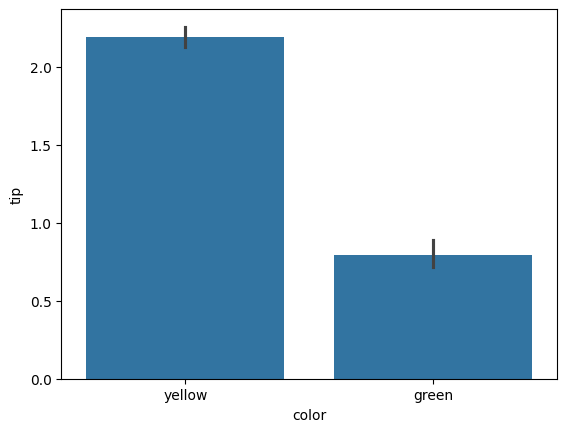

In [ ]:
sns.barplot(x=df.color,y=df.tip)

Yellow taxis receive higher average tips than green taxis

Green taxis show lower or near-zero average tips

<Axes: xlabel='color', ylabel='tip'>

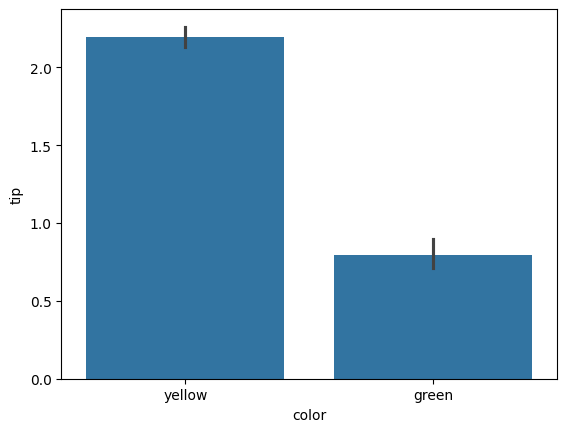

In [ ]:
sns.barplot(x=df.color,y=df.tip,estimator='mean')

Mean tips are higher for yellow taxis than green taxis, indicating differences in service areas and payment behavior.

#HistPlot
Insights:

Most tips are small

Few tips are large

Yellow taxi have much high frequency

Green taxis have fewer tips

<Axes: xlabel='tip', ylabel='Count'>

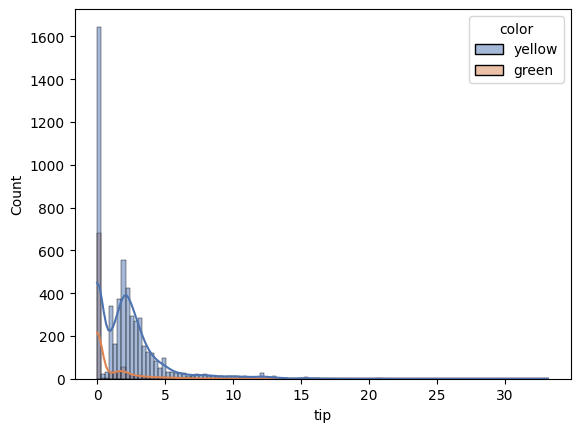

In [ ]:
sns.histplot(x=df.tip,hue=df.color,kde=True,palette='deep')

Null hypothesis (H₀): Mean tip (green) = Mean tip (yellow)

Alternative (H₁): Mean tips are different

t_stat → size & direction of difference

p_val → statistical significance

📌 Interpretation

If p_val < 0.05 → Reject H₀
👉 Mean tips differ significantly by taxi color

If p_val ≥ 0.05 → Fail to reject H₀
👉 No significant difference in mean tips

In [ ]:
# Independent T-Test
from scipy import stats
green_tip = df[df['color']=='green']['tip']
yellow_tip = df[df['color']=='yellow']['tip']
t_stat, p_val = stats.ttest_ind(green_tip,yellow_tip)
print("Independent T-Test statistic:", t_stat)
print("P-value:", p_val)
if p_val < 0.05:
    print("Reject null hypothesis: Income differs by Gender")
else:
    print("Fail to reject null hypothesis: No significant income difference by Gender")

Independent T-Test statistic: -16.814613238868215
P-value: 3.990448033473455e-62
Reject null hypothesis: Income differs by Gender


In [ ]:
df=df.dropna()

In [ ]:
# Independent T-Test
from scipy import stats
green_tip = df[df['payment']=='credit card']['tip']
yellow_tip = df[df['payment']=='cash']['tip']
t_stat, p_val = stats.ttest_ind(green_tip,yellow_tip)
print("Independent T-Test statistic:", t_stat)
print("P-value:", p_val)
if p_val < 0.05:
    print("Reject null hypothesis: Income differs by Gender")
else:
    print("Fail to reject null hypothesis: No significant income difference by Gender")

Independent T-Test statistic: 49.09538452722153
P-value: 0.0
Reject null hypothesis: Income differs by Gender


<Axes: xlabel='payment', ylabel='tip'>

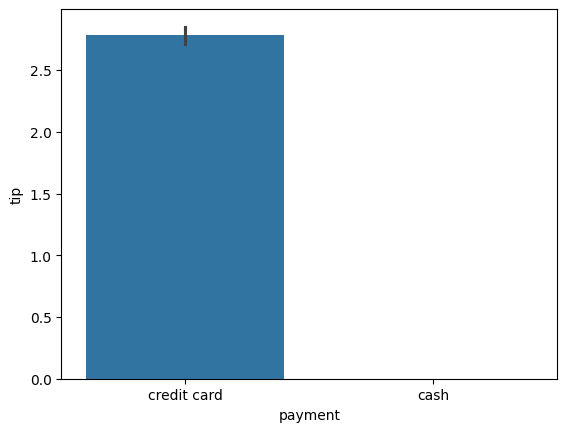

In [ ]:
sns.barplot(x=df.payment,y=df.tip,estimator='mean')

<Axes: xlabel='tip', ylabel='Count'>

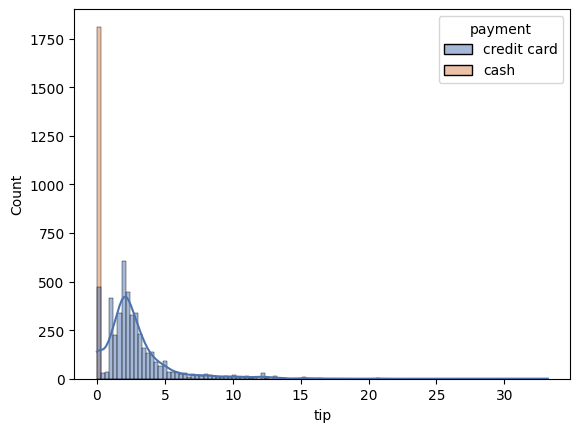

In [ ]:
sns.histplot(x=df['tip'],hue=df['payment'],kde=True,palette='deep')

In [ ]:
from pandas.core.api import value_counts
df['pickup_borough'].value_counts()

,count
pickup_borough,
Manhattan,5226
Queens,638
Brooklyn,378
Bronx,99


/tmp/ipython-input-1412076334.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['pickup_borough'],palette='deep')


<Axes: xlabel='pickup_borough', ylabel='count'>

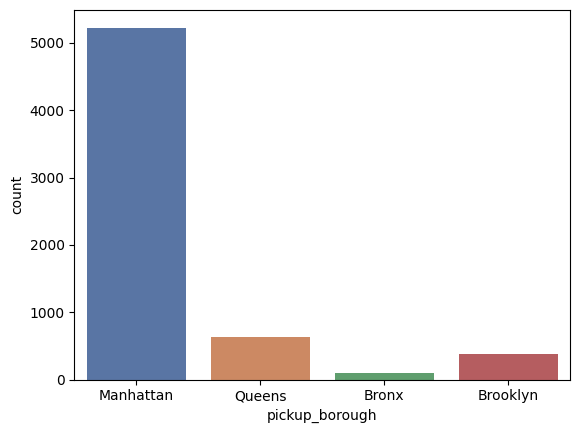

In [ ]:
sns.countplot(x=df['pickup_borough'],palette='deep')

In [ ]:
df['tip'].groupby(df['pickup_borough']).mean()

,tip
pickup_borough,
Bronx,0.148586
Brooklyn,0.979127
Manhattan,1.945597
Queens,3.066458


<Axes: xlabel='tip', ylabel='Count'>

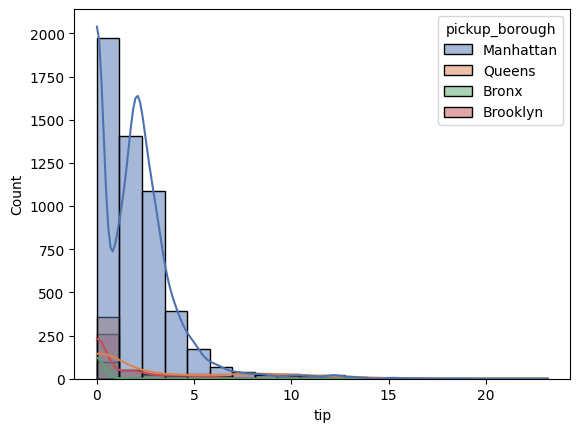

In [ ]:
sns.histplot(x=df.tip,hue=df['pickup_borough'],bins=20,kde=True,palette='deep')

#Hypothesis:

H0: distribution of tip is same across of all pickup_borough category

H1: atleast 1 category have different distribution of tips

In [ ]:
manhattan_tip=df['tip'][df['pickup_borough']=='Manhattan']
brooklyn_tip=df['tip'][df['pickup_borough']=='Brooklyn']
queens_tip=df['tip'][df['pickup_borough']=='Queens']
bronx_tip=df['tip'][df['pickup_borough']=='Bronx']
stat,p_value=stats.f_oneway(manhattan_tip,brooklyn_tip,queens_tip,bronx_tip)

H₀ (Null): Mean tip is the same in all regions
(Manhattan = Queens = Bronx = Brooklyn)

H₁ (Alt): At least one region’s mean tip is different

🔢 Output Meaning

F-statistic: Ratio of between-group variance to within-group variance

P-value: Statistical significance

📌 Interpretation

p_val < 0.05 → Reject H₀
👉 Mean tips differ by region

p_val ≥ 0.05 → Fail to reject H₀
👉 No significant difference in mean tips across regions

In [ ]:
# ANOVA Test
#regions = [group['Spending_Score'].values for name, group in df.groupby('Region')]
f_stat, p_val = stats.f_oneway(manhattan_tip,queens_tip,bronx_tip,brooklyn_tip)
print("ANOVA F-statistic:", f_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Reject null hypothesis: Spending Score differs by Region")
else:
    print("Fail to reject null hypothesis: No significant difference by Region")

ANOVA F-statistic: 91.5793383185057
P-value: 5.155109332422435e-58
Reject null hypothesis: Spending Score differs by Region


Applied after ANOVA

Compares every pair of boroughs

Tells which specific pairs differ in mean tips

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD
tukey_result = pairwise_tukeyhsd(endog=df.tip, groups=df.pickup_borough, alpha=0.05)
print(tukey_result)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
  group1    group2  meandiff p-adj lower  upper  reject
-------------------------------------------------------
    Bronx  Brooklyn   0.8305 0.008 0.1595 1.5015   True
    Bronx Manhattan    1.797   0.0  1.194    2.4   True
    Bronx    Queens   2.9179   0.0 2.2759 3.5599   True
 Brooklyn Manhattan   0.9665   0.0 0.6499  1.283   True
 Brooklyn    Queens   2.0873   0.0 1.7016 2.4731   True
Manhattan    Queens   1.1209   0.0 0.8716 1.3701   True
-------------------------------------------------------


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD
tukey_result = pairwise_tukeyhsd(endog=df.tip, groups=df.dropoff_borough, alpha=0.05)
print(tukey_result)


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1      group2    meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
    Bronx      Brooklyn   1.3869    0.0  0.7691  2.0046   True
    Bronx     Manhattan   1.4296    0.0  0.8751  1.9842   True
    Bronx        Queens   1.8873    0.0  1.2742  2.5005   True
    Bronx Staten Island  13.6303    0.0  9.0833 18.1773   True
 Brooklyn     Manhattan   0.0427 0.9952 -0.2571  0.3425  False
 Brooklyn        Queens   0.5004 0.0055  0.1026  0.8983   True
 Brooklyn Staten Island  12.2434    0.0  7.7204 16.7664   True
Manhattan        Queens   0.4577 0.0002  0.1675  0.7479   True
Manhattan Staten Island  12.2007    0.0  7.6859 16.7154   True
   Queens Staten Island   11.743    0.0  7.2206 16.2653   True
--------------------------------------------------------------


In [ ]:
manhattan_tip=df['tip'][df['dropoff_borough']=='Manhattan']
brooklyn_tip=df['tip'][df['dropoff_borough']=='Brooklyn']
queens_tip=df['tip'][df['dropoff_borough']=='Queens']
bronx_tip=df['tip'][df['dropoff_borough']=='Bronx']
stat,p_value=stats.f_oneway(manhattan_tip,brooklyn_tip,queens_tip,bronx_tip)

In [ ]:
# ANOVA Test
#regions = [group['Spending_Score'].values for name, group in df.groupby('Region')]
f_stat, p_val = stats.f_oneway(manhattan_tip,queens_tip,bronx_tip,brooklyn_tip)
print("ANOVA F-statistic:", f_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Reject null hypothesis: Spending Score differs by Region")
else:
    print("Fail to reject null hypothesis: No significant difference by Region")

ANOVA F-statistic: 23.78981400797117
P-value: 2.6378206902104746e-15
Reject null hypothesis: Spending Score differs by Region


<Axes: xlabel='tip', ylabel='Count'>

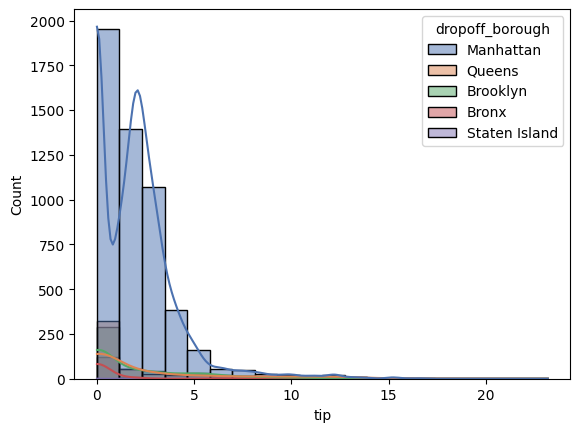

In [ ]:
sns.histplot(x=df.tip,hue=df['dropoff_borough'],bins=20,kde=True,palette='deep')

/tmp/ipython-input-1469782604.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['dropoff_borough'],palette='deep')


<Axes: xlabel='dropoff_borough', ylabel='count'>

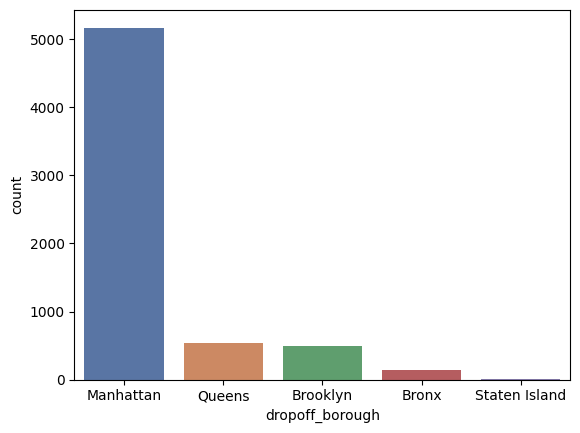

In [ ]:
sns.countplot(x=df['dropoff_borough'],palette='deep')

In [ ]:
# ANOVA Test
categories = [group['tip'].values for name, group in df.groupby('dropoff_zone')]
f_stat, p_val = stats.f_oneway(*categories)
print("ANOVA F-statistic:", f_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")



ANOVA F-statistic: 5.76903467327541
P-value: 1.3107168403745948e-120
Reject null hypothesis


In [ ]:
r, p_val = stats.pearsonr(df['tip'], df['fare'])
print("correlation", r)
print("P-value:", p_val)

alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis: ")
else:
    print("Fail to reject null hypothesis: ")


correlation 0.48710089077355956
P-value: 0.0
Reject null hypothesis: 


<Axes: xlabel='tip', ylabel='fare'>

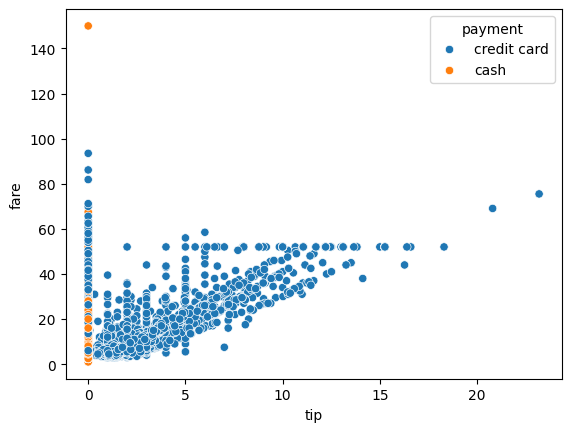

In [ ]:
sns.scatterplot(x=df['tip'],y=df['fare'],hue=df['payment'])

<Axes: xlabel='tip', ylabel='distance'>

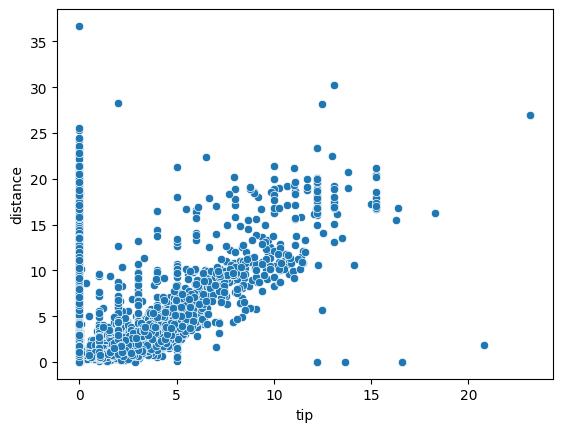

In [ ]:
sns.scatterplot(x=df['tip'],y=df['distance'])

<Axes: xlabel='tip', ylabel='distance'>

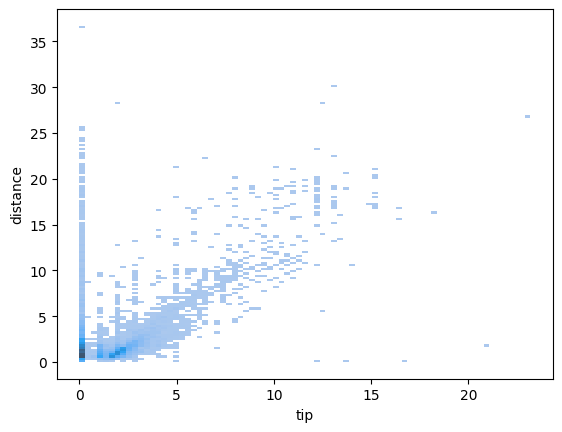

In [ ]:
sns.histplot(x=df['tip'],y=df['distance'])

<Axes: >

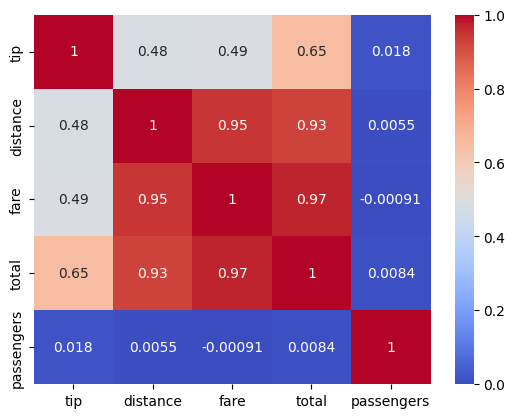

In [ ]:

sns.heatmap(df[['tip','distance','fare','total','passengers']].corr(), annot=True, cmap='coolwarm')


<Axes: xlabel='tip', ylabel='total'>

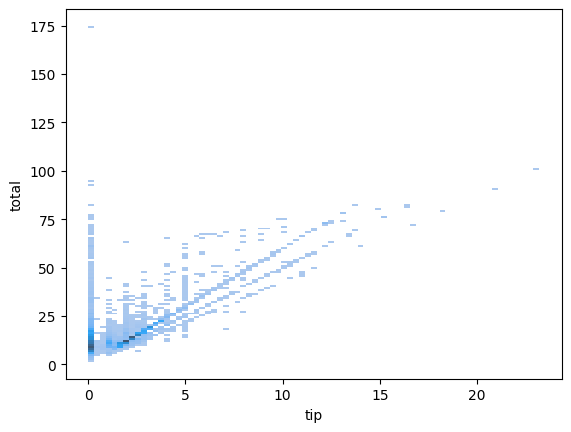

In [ ]:
sns.histplot(x=df['tip'],y=df['total'])

<Axes: xlabel='tip', ylabel='total'>

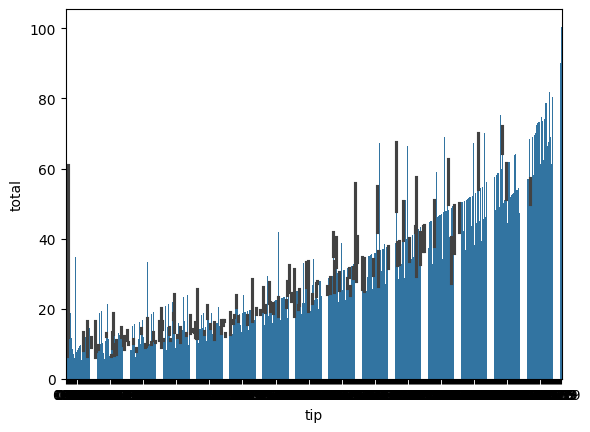

In [ ]:
sns.barplot(x=df['tip'],y=df['total'])